# LSTM

## Import libraries

In [356]:
import ccxt
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt

## Constants

In [357]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2010-11-03T20:00:00Z")
TIMEFRAME = "1d"
LAGS_NUM = 24
TRAIN_TEST_SPLIT_RATIO = 0.7
HIDDEN_NEURONS_NUM = 50
EPOCHS_NUM = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
PATIENCE_NUM = 30
BINARY_CLASSIFICATION = True
SELECTKBEST = False

In [358]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

## Fetching data

In [359]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=1000,
        )
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [360]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377
2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264
2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022
2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060


### Verifying duplicates

In [361]:
data.index.duplicated().sum()

0

### Verifying continuous of data

In [362]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='D')


## Processing data

In [363]:
data['log_return_close'] = np.log(data['Close'].shift(1) / data['Close'].shift(2))
data['log_return_open'] = np.log(data['Open'].shift(1) / data['Open'].shift(2))
data['log_return_high'] = np.log(data['High'].shift(1) / data['High'].shift(2))
data['log_return_low'] = np.log(data['Low'].shift(1) / data['Low'].shift(2))

In [364]:
data['log_spread_hl'] = np.log(data['High'].shift(1) / data['Low'].shift(1))
data['log_spread_co'] = np.log(data['Close'].shift(1) / data['Open'].shift(1))

In [365]:
data['moving_average_return_close'] = data['log_return_close'].rolling(window=LAGS_NUM).mean()
data['deviation_return_close'] = data['log_return_close'].rolling(window=LAGS_NUM).std()

In [366]:
data['volatility_ratio'] = data['log_return_close'].rolling(window=LAGS_NUM).std() / data['log_return_close'].rolling(window=LAGS_NUM).mean()

In [367]:
data['true_range'] = np.maximum(data['High'].shift(1) - data['Low'].shift(1), np.maximum(np.abs(data['High'].shift(1) - data['Close'].shift(2)), np.abs(data['Low'].shift(1) - data['Close'].shift(2))))
data['average_true_range'] = data['true_range'].rolling(window=LAGS_NUM).mean()

In [368]:
data['velocity'] = data['Close'].shift(1) - data['Close'].shift(2)
data['acceleration'] = data['velocity'] - data['velocity'].shift(1)

In [369]:
data['volume_mean'] = data['Volume'].shift(1).rolling(window=LAGS_NUM).mean()
data['volume_std'] = data['Volume'].shift(1).rolling(window=LAGS_NUM).std()
data['delta_volume'] = (data['Volume'].shift(1) - data['volume_mean']) / data['volume_std']

In [370]:
data['return_close'] = (data['Close'] - data['Close'].shift(1)) / data['Close'].shift(1)

In [371]:
data['return_close_binary'] = (data['return_close'] > 0).astype(int)

In [372]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,log_return_open,log_return_high,log_return_low,log_spread_hl,...,volatility_ratio,true_range,average_true_range,velocity,acceleration,volume_mean,volume_std,delta_volume,return_close,return_close_binary
Date,,,,,,,,,,,,,,,,,,,,,
2017-09-11,4153.62,4334.43,4098.91,4208.47,699.989065,-0.030623,-0.005617,-0.032983,-0.087859,0.119390,...,-27.648653,482.00,365.057917,-128.44,-104.45,741.012867,296.506525,-0.271966,0.018909,1
2017-09-12,4208.60,4394.59,4040.80,4163.72,879.630319,0.018732,-0.025010,0.011936,0.075457,0.055869,...,41.517044,235.52,356.840000,78.10,206.54,720.183733,279.966970,-0.072132,-0.010633,0
2017-09-13,4159.72,4165.38,3760.00,3944.69,913.462545,-0.010690,0.013150,0.013784,-0.014278,0.083932,...,174.960034,353.79,357.635833,-44.75,-122.85,740.947090,272.110547,0.509658,-0.052604,0
2017-09-14,3944.00,3993.00,3165.13,3189.02,1665.021543,-0.054039,-0.011682,-0.053567,-0.072024,0.102389,...,-29.309091,405.38,367.090833,-219.03,-174.28,759.546237,267.798855,0.574746,-0.191566,0
2017-09-15,3188.01,3856.00,2817.00,3700.00,1968.866492,-0.212657,-0.053252,-0.042265,-0.172225,0.232349,...,-6.343405,827.87,392.925833,-755.67,-536.64,800.099507,324.726765,2.663538,0.160231,1


In [373]:
X = data.drop(columns=['return_close_binary', 'return_close', 'High', 'Low', 'Open', 'Close', 'Volume'])
if BINARY_CLASSIFICATION:
    y = data['return_close_binary']
else:
    y = data['return_close']

In [374]:
X.head()

,log_return_close,log_return_open,log_return_high,log_return_low,log_spread_hl,log_spread_co,moving_average_return_close,deviation_return_close,volatility_ratio,true_range,average_true_range,velocity,acceleration,volume_mean,volume_std,delta_volume
Date,,,,,,,,,,,,,,,,
2017-09-11,-0.030623,-0.005617,-0.032983,-0.087859,0.119390,-0.030623,-0.001532,0.042363,-27.648653,482.00,365.057917,-128.44,-104.45,741.012867,296.506525,-0.271966
2017-09-12,0.018732,-0.025010,0.011936,0.075457,0.055869,0.013119,0.001003,0.041643,41.517044,235.52,356.840000,78.10,206.54,720.183733,279.966970,-0.072132
2017-09-13,-0.010690,0.013150,0.013784,-0.014278,0.083932,-0.010721,0.000238,0.041684,174.960034,353.79,357.635833,-44.75,-122.85,740.947090,272.110547,0.509658
2017-09-14,-0.054039,-0.011682,-0.053567,-0.072024,0.102389,-0.053077,-0.001469,0.043069,-29.309091,405.38,367.090833,-219.03,-174.28,759.546237,267.798855,0.574746
2017-09-15,-0.212657,-0.053252,-0.042265,-0.172225,0.232349,-0.212482,-0.009607,0.060942,-6.343405,827.87,392.925833,-755.67,-536.64,800.099507,324.726765,2.663538


## Spliting data

In [375]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)

In [376]:
print(X_train.shape, y_train.shape)

(2193, 16) (2193,)


In [377]:
X_labels = X_train.columns
if SELECTKBEST:
    f = None
    if BINARY_CLASSIFICATION:
        print("Binary classification")
        f = f_classif
    else:
        print("Regression")
        f = f_regression
    X_labels = SelectKBest(f, k=8).fit(X_train, y_train).get_feature_names_out(X.columns)
    X_train = X_train[X_labels]
    X_val = X_val[X_labels]
    X_test = X_test[X_labels]
    print("Selected features:", X_labels)
X_train.head()

,log_return_close,log_return_open,log_return_high,log_return_low,log_spread_hl,log_spread_co,moving_average_return_close,deviation_return_close,volatility_ratio,true_range,average_true_range,velocity,acceleration,volume_mean,volume_std,delta_volume
Date,,,,,,,,,,,,,,,,
2017-09-11,-0.030623,-0.005617,-0.032983,-0.087859,0.119390,-0.030623,-0.001532,0.042363,-27.648653,482.00,365.057917,-128.44,-104.45,741.012867,296.506525,-0.271966
2017-09-12,0.018732,-0.025010,0.011936,0.075457,0.055869,0.013119,0.001003,0.041643,41.517044,235.52,356.840000,78.10,206.54,720.183733,279.966970,-0.072132
2017-09-13,-0.010690,0.013150,0.013784,-0.014278,0.083932,-0.010721,0.000238,0.041684,174.960034,353.79,357.635833,-44.75,-122.85,740.947090,272.110547,0.509658
2017-09-14,-0.054039,-0.011682,-0.053567,-0.072024,0.102389,-0.053077,-0.001469,0.043069,-29.309091,405.38,367.090833,-219.03,-174.28,759.546237,267.798855,0.574746
2017-09-15,-0.212657,-0.053252,-0.042265,-0.172225,0.232349,-0.212482,-0.009607,0.060942,-6.343405,827.87,392.925833,-755.67,-536.64,800.099507,324.726765,2.663538


## Verifying data distribution

array([[<Axes: title={'center': 'log_return_close'}>,
        <Axes: title={'center': 'log_return_open'}>,
        <Axes: title={'center': 'log_return_high'}>,
        <Axes: title={'center': 'log_return_low'}>],
       [<Axes: title={'center': 'log_spread_hl'}>,
        <Axes: title={'center': 'log_spread_co'}>,
        <Axes: title={'center': 'moving_average_return_close'}>,
        <Axes: title={'center': 'deviation_return_close'}>],
       [<Axes: title={'center': 'volatility_ratio'}>,
        <Axes: title={'center': 'true_range'}>,
        <Axes: title={'center': 'average_true_range'}>,
        <Axes: title={'center': 'velocity'}>],
       [<Axes: title={'center': 'acceleration'}>,
        <Axes: title={'center': 'volume_mean'}>,
        <Axes: title={'center': 'volume_std'}>,
        <Axes: title={'center': 'delta_volume'}>]], dtype=object)

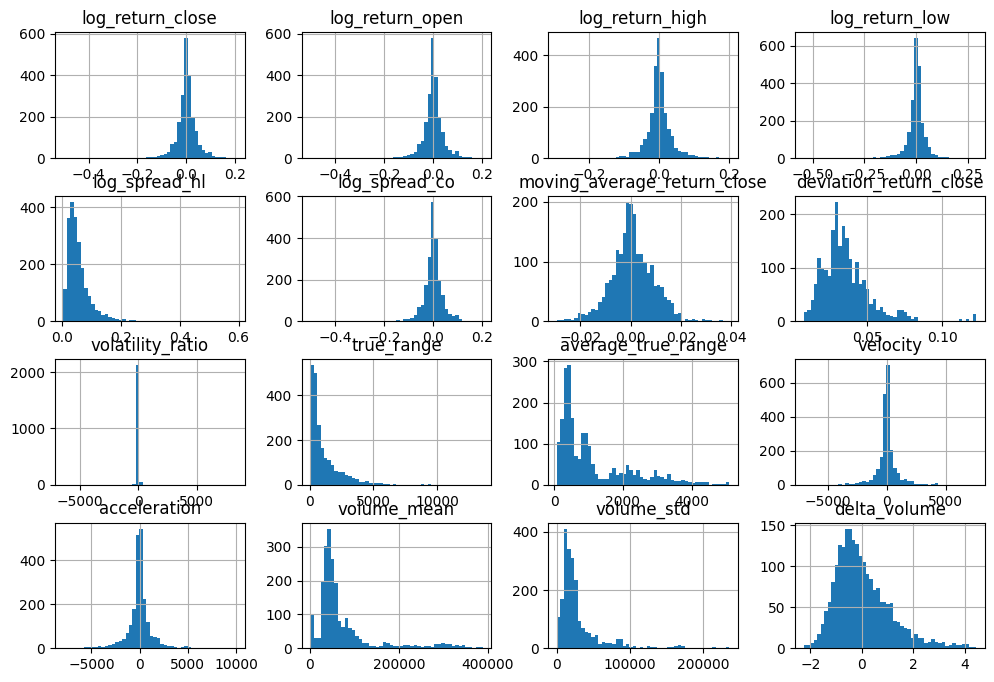

In [378]:
X_train.hist(figsize=(12, 8), bins=50)

## Scaling data

In [379]:
def scale_data(X, y, lags_num, scaler_X=None, binary_classification=False, scaler_y=None):
    # scale X and create lags
    if scaler_X is None:
        scaler_X = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
    else:
        X_scaled = scaler_X.transform(X)
    X_scaled_lags = []
    y = y.values
    y_lags = []
    for i in range(lags_num, X_scaled.shape[0]):
        X_scaled_lags.append(X_scaled[i-lags_num:i])
        y_lags.append(y[i])
    X_scaled_lags = np.array(X_scaled_lags)
    y_lags = np.array(y_lags)
    # scale y if regression, convert to int if binary classification
    if binary_classification:
        y_lags = y_lags.astype(int)
    else:
        if scaler_y is None:
            scaler_y = StandardScaler()
            y_lags = scaler_y.fit_transform(y_lags.reshape(-1, 1))
        else:
            y_lags = scaler_y.transform(y_lags.reshape(-1, 1))
    # reshape for LSTM input
    X_scaled_lags = X_scaled_lags.reshape((-1, X_scaled_lags.shape[1], X_scaled_lags.shape[2]))
    y_lags = y_lags.reshape(-1, 1)
    return X_scaled_lags, y_lags, scaler_X, scaler_y


In [380]:
X_train, y_train, scaler_X, scaler_y = scale_data(X_train, y_train, LAGS_NUM, binary_classification=BINARY_CLASSIFICATION)
X_val, y_val, _, _ = scale_data(X_val, y_val, LAGS_NUM, scaler_X, scaler_y=scaler_y, binary_classification=BINARY_CLASSIFICATION)
X_test, y_test, _, _ = scale_data(X_test, y_test, LAGS_NUM, scaler_X, scaler_y=scaler_y, binary_classification=BINARY_CLASSIFICATION)

In [381]:
print(X_labels)

Index(['log_return_close', 'log_return_open', 'log_return_high',
       'log_return_low', 'log_spread_hl', 'log_spread_co',
       'moving_average_return_close', 'deviation_return_close',
       'volatility_ratio', 'true_range', 'average_true_range', 'velocity',
       'acceleration', 'volume_mean', 'volume_std', 'delta_volume'],
      dtype='str')


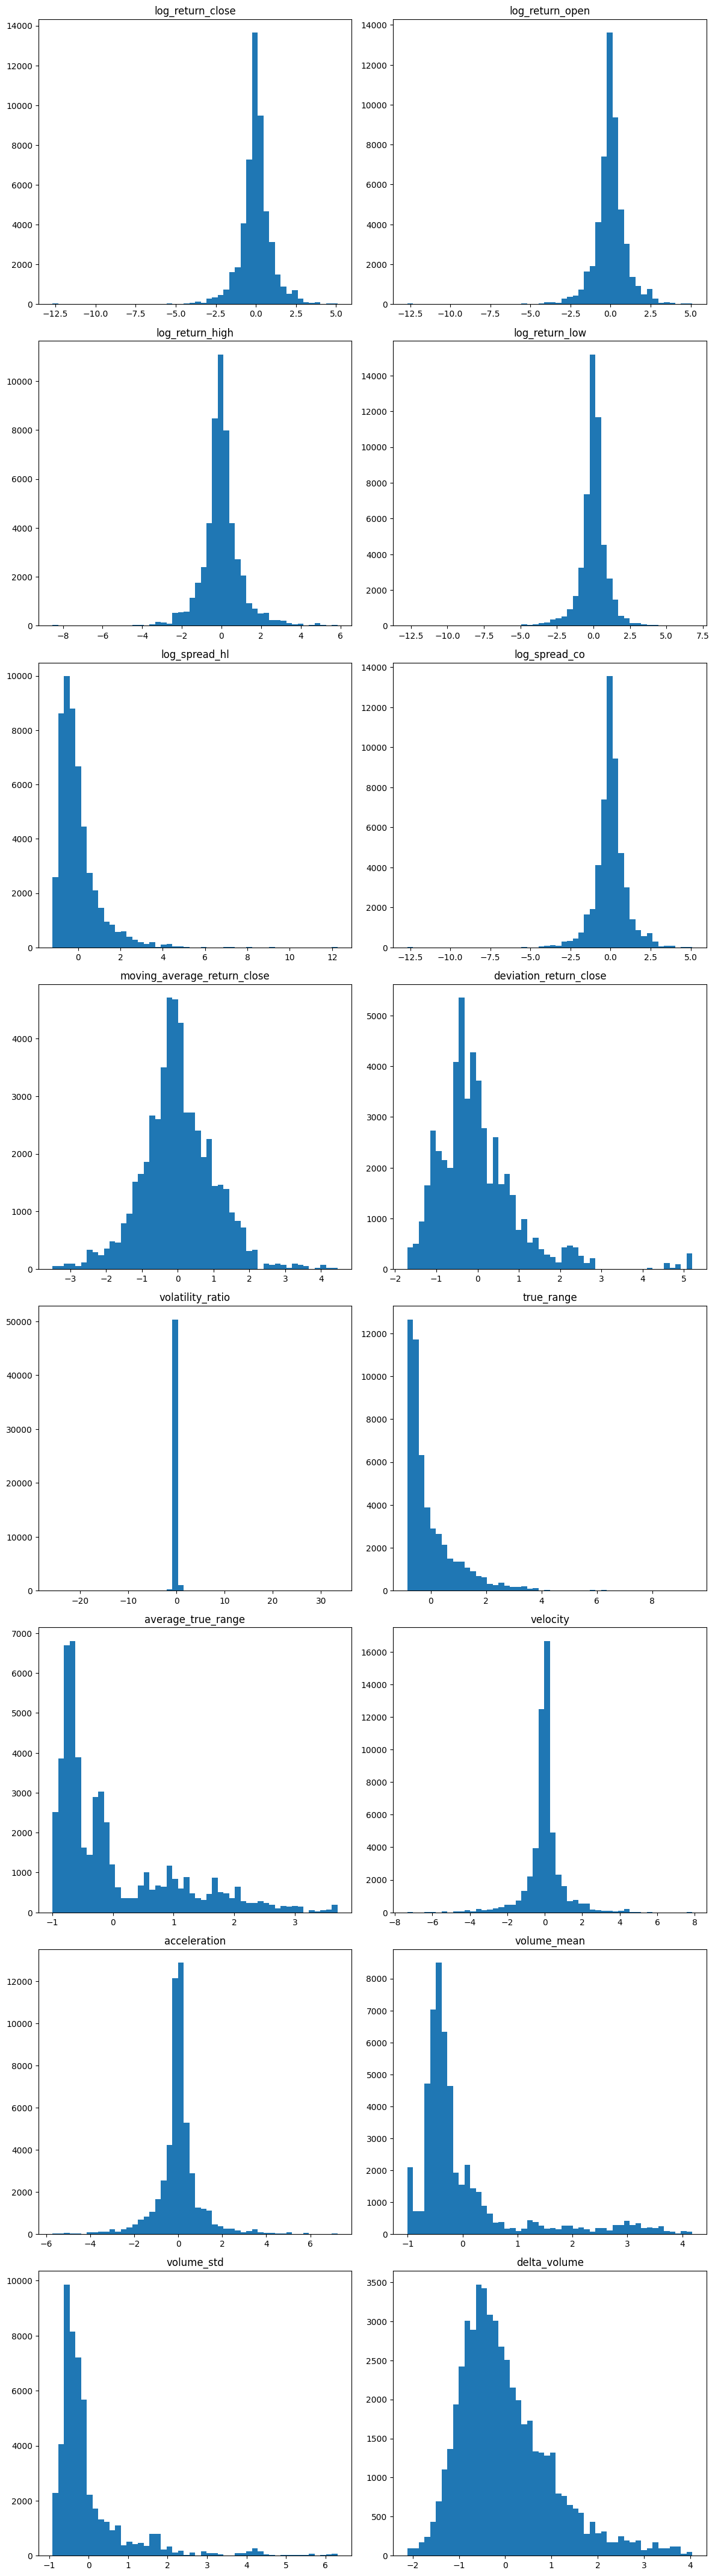

In [382]:
plt.figure(figsize=(12, 48))
# Plot the distribution of the all features in the training set
for i in range(X_train.shape[2]):
    plt.subplot(X_train.shape[2]//2+1, 2, i+1)
    plt.hist(X_train[:, :, i].flatten(), bins=50)
    plt.title(X_labels[i])
plt.tight_layout()
plt.show()

## Building and training model

In [383]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(HIDDEN_NEURONS_NUM))
model.add(Dropout(DROPOUT_RATE))
if BINARY_CLASSIFICATION:
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 50)             │        13,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,502 (52.74 KB)

 Trainable params: 13,502 (52.74 KB)

 Non-trainable params: 0 (0.00 B)

In [384]:
if BINARY_CLASSIFICATION:
    print("Binary classification")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_accuracy', patience=PATIENCE_NUM, restore_best_weights=True)])
else:
    print("Regression")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_mae', patience=PATIENCE_NUM, restore_best_weights=True)])

Binary classification
Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5025 - loss: 0.7047 - val_accuracy: 0.4641 - val_loss: 0.7011
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5039 - loss: 0.6970 - val_accuracy: 0.4798 - val_loss: 0.7008
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5380 - loss: 0.6902 - val_accuracy: 0.5135 - val_loss: 0.6997
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5293 - loss: 0.6902 - val_accuracy: 0.4865 - val_loss: 0.7041
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5417 - loss: 0.6862 - val_accuracy: 0.4753 - val_loss: 0.7108
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5330 - loss: 0.6867 - val_accuracy: 0.4619 - val_loss: 0.7123
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5500 - loss: 0.6852 - val_accuracy: 0.4641 - val_loss: 0.7139
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5574 - loss: 0.6818 - v

## Verifying model

In [385]:
y_pred = model.predict(X_test)
if BINARY_CLASSIFICATION:
    y_pred = np.argmax(y_pred, axis=1)
else:
    y_pred = scaler_y.inverse_transform(y_pred.flatten().reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.flatten().reshape(-1, 1)).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [386]:
print(y_test.flatten()[:10])
print(y_pred.flatten()[:10])

[0 1 1 0 1 1 0 0 0 0]
[0 0 1 0 0 0 0 0 0 0]


In [387]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test.flatten(), y_pred))
else:
    print("Regression metrics would be printed here.")
    Directional_accuracy = np.mean((y_pred > 0) == (y_test.flatten() > 0))
    print(f"Directional accuracy: {Directional_accuracy:.4f}")

              precision    recall  f1-score   support

           0       0.51      0.71      0.60       229
           1       0.49      0.29      0.36       217

    accuracy                           0.51       446
   macro avg       0.50      0.50      0.48       446
weighted avg       0.50      0.51      0.48       446



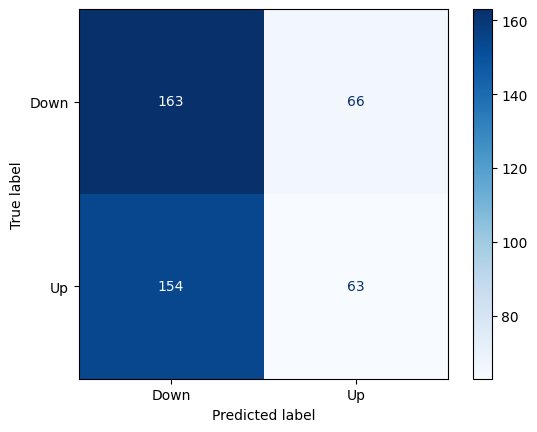

In [388]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test.flatten(), y_pred, cmap='Blues', display_labels=["Down", "Up"])
else:
    print("Confusion matrix is not applicable for regression.")
    plt.figure(figsize=(12, 8))
    plt.plot(y_test.flatten(), label='True')
    plt.plot(y_pred.flatten()/10, label='Predicted')
    plt.legend()
    plt.show()

## Backtesting model